
--- Test Set Evaluation ---
MAE: 15157.87
MSE: 1807209642.54
RMSE: 42511.29
R2 Score: 0.0636
Adjusted R2 Score: 0.0539


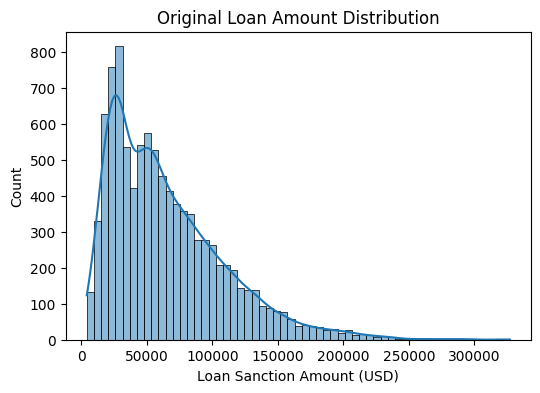

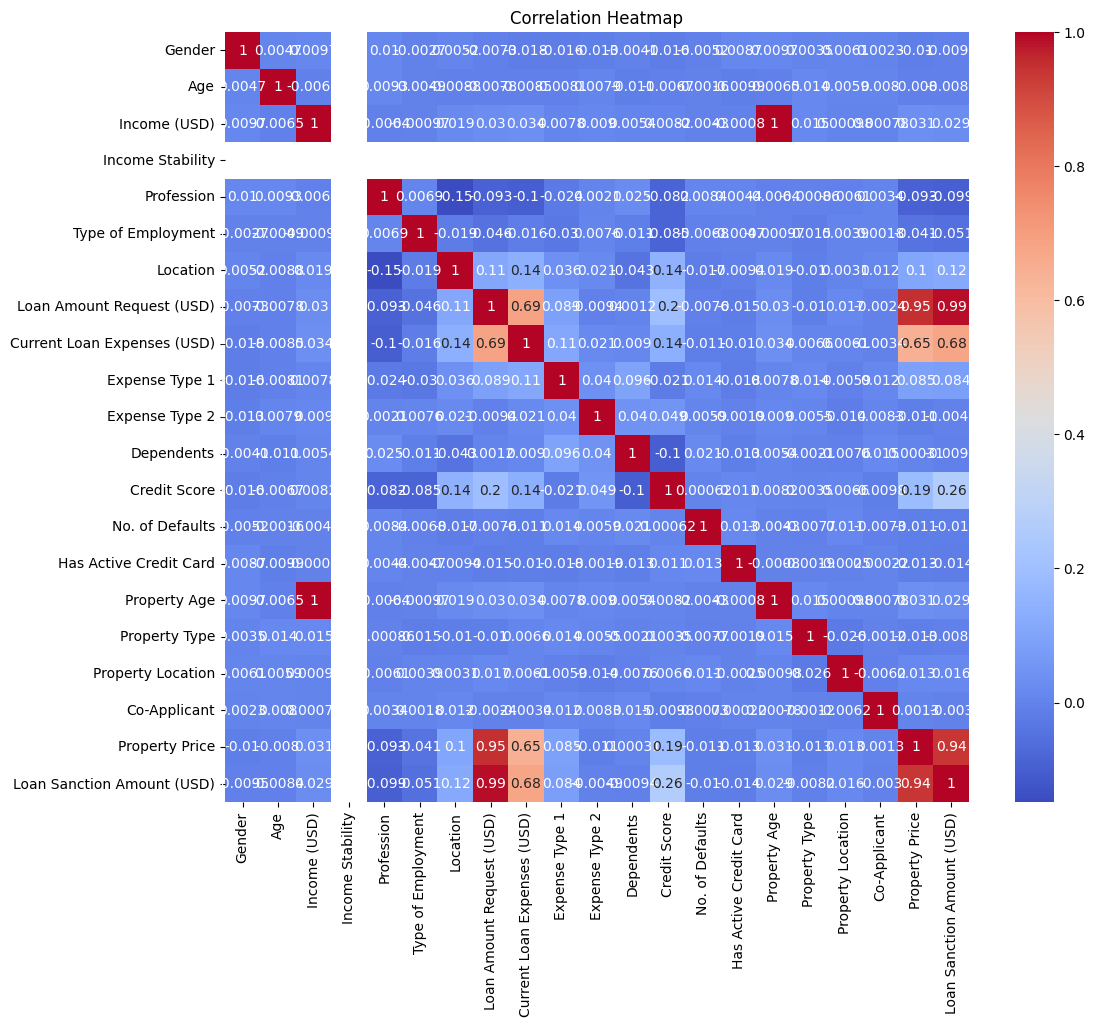

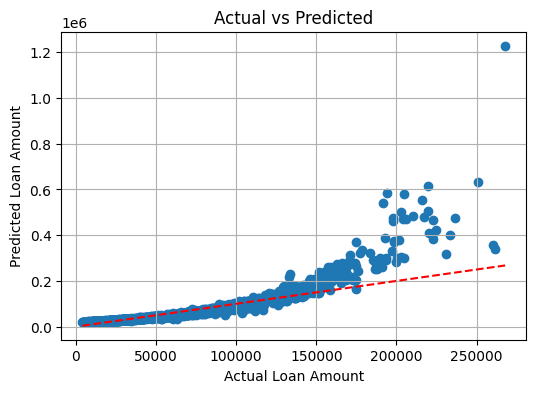

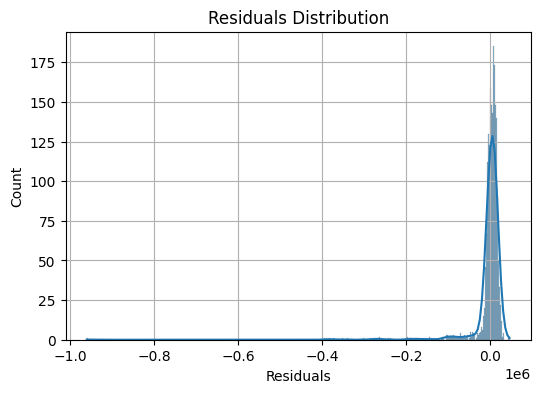

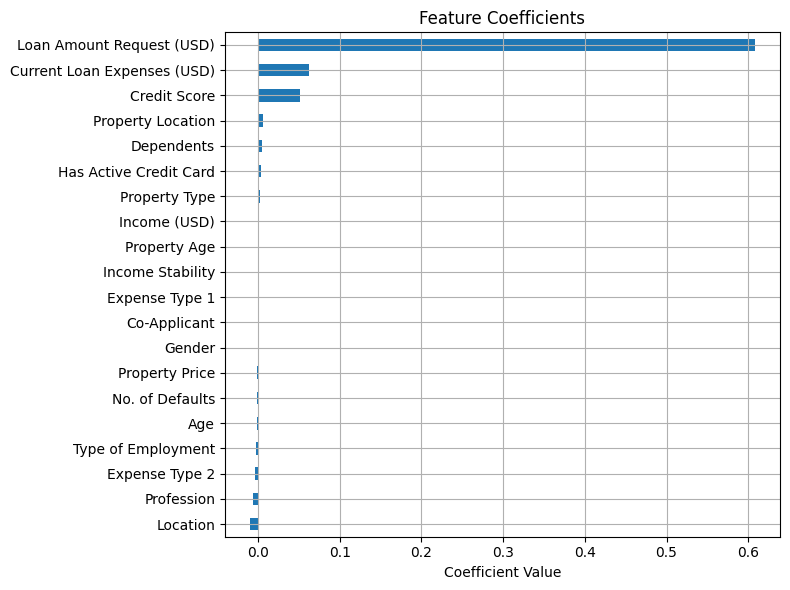


--- Cross-Validation (5-Fold) ---
Average MAE: 13123.89
Average MSE: 5191.09
Average RMSE: 18402.20
Average R2 Score: 0.8458


In [ ]:
# Experiment 2: Loan Amount Prediction using Linear Regression (Cleaned Version)

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load Dataset
df = pd.read_csv("train.csv")

# 2. Drop rows where target is missing or <= 0 (invalid for log)
df = df[df["Loan Sanction Amount (USD)"].notnull()]
df = df[df["Loan Sanction Amount (USD)"] > 0]

# 3. Drop rows with missing values in general
df.dropna(inplace=True)

# 4. Select only required features
selected_features = [
    'Gender', 'Age', 'Income (USD)', 'Income Stability', 'Profession',
    'Type of Employment', 'Location', 'Loan Amount Request (USD)',
    'Current Loan Expenses (USD)', 'Expense Type 1', 'Expense Type 2',
    'Dependents', 'Credit Score', 'No. of Defaults',
    'Has Active Credit Card', 'Property Age', 'Property Type',
    'Property Location', 'Co-Applicant', 'Property Price',
    'Loan Sanction Amount (USD)'
]
df = df[selected_features]

# 5. Encode categorical features
categorical_cols = df.select_dtypes(include='object').columns.tolist()
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df[categorical_cols] = encoder.fit_transform(df[categorical_cols])

# 6. Separate features and target
X = df.drop("Loan Sanction Amount (USD)", axis=1)
y = df["Loan Sanction Amount (USD)"]

# 7. Apply log transformation on target
y_log = np.log1p(y)

# 8. Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 9. Train/test split
X_train, X_test, y_train_log, y_test_log = train_test_split(X_scaled, y_log, test_size=0.2, random_state=42)

# 10. Train model
model = LinearRegression()
model.fit(X_train, y_train_log)

# 11. Predict and inverse transform
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)  # back to original scale
y_test = np.expm1(y_test_log)

# 12. Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
n, p = X_test.shape
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("\n--- Test Set Evaluation ---")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"Adjusted R2 Score: {adjusted_r2:.4f}")

# 13. Visualizations

# Histogram of target
plt.figure(figsize=(6, 4))
sns.histplot(y, kde=True)
plt.title("Original Loan Amount Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Actual vs Predicted
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()

# Residual plot
residuals = y_test - y_pred
plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.xlabel("Residuals")
plt.grid(True)
plt.show()

# Feature coefficients
coefficients = pd.Series(model.coef_, index=X.columns)
coefficients.sort_values().plot(kind='barh', figsize=(8, 6), title="Feature Coefficients")
plt.xlabel("Coefficient Value")
plt.grid(True)
plt.tight_layout()
plt.show()

# 14. Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
mae_scores = cross_val_score(model, X_scaled, y_log, cv=kf, scoring='neg_mean_absolute_error')
mse_scores = cross_val_score(model, X_scaled, y_log, cv=kf, scoring='neg_mean_squared_error')
r2_scores = cross_val_score(model, X_scaled, y_log, cv=kf, scoring='r2')

print("\n--- Cross-Validation (5-Fold) ---")
print(f"Average MAE: {-mae_scores.mean()*df['Loan Sanction Amount (USD)'].mean():.2f}")
print(f"Average MSE: {-mse_scores.mean()*df['Loan Sanction Amount (USD)'].mean():.2f}")
print(f"Average RMSE: {np.sqrt(-mse_scores.mean())*df['Loan Sanction Amount (USD)'].mean():.2f}")
print(f"Average R2 Score: {r2_scores.mean():.4f}")
